# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [15]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [16]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [17]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [18]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [19]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [20]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [24]:
### Ejercicio 1
from pyspark.sql import functions as F

# Muestra el esquema completo.
agg_df.printSchema()
df_resultados = spark.read.parquet("resultados/")

# Indica cuántas filas contiene.
filas_totales = df_resultados.count()

# ¿Cuántos sensores distintos (sensor_id) aparecen?
sensores_totales = df_resultados.select("sensor_id").distinct().count()

print(f"El DF tiene {filas_totales} filas")
print(f"Hay un total de {sensores_totales} sensores distintos")

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

El DF tiene 128 filas
Hay un total de 4 sensores distintos


In [25]:
### Ejercicio 2
# Crea una columna basada en la diferencia o relación entre dos métricas numéricas del DataFrame
df_resultados = df_resultados.withColumn('rango_metrica', df_resultados['avg_temp'] - df_resultados['avg_humidity'])

# ¿Cuál es el valor mínimo, máximo y medio de la nueva columna?
df_resultados.select("rango_metrica").summary("min", "max", "mean").show()

+-------+--------------------+
|summary|       rango_metrica|
+-------+--------------------+
|    min| -32.373333333333335|
|    max|   49.88999999999999|
|   mean|-0.15724134741127027|
+-------+--------------------+



In [28]:
### Ejercicio 3
# Aplica un filtro usando varias condiciones a la vez relacionadas con:
  # humedad,
  # número de eventos,
  # sensor.

df_filtro = (df_resultados
               .filter(df_resultados["avg_humidity"] > 20)
               .filter(df_resultados["num_events"] > 5)
               .filter(df_resultados["sensor_id"] < "S2"))

# ¿Cuántos registros cumplen todas las condiciones aplicadas?
print(f"Hay un total de {df_filtro.count()} registros que cumplen todas las condiciones aplicadas")

Hay un total de 20 registros que cumplen todas las condiciones aplicadas


In [32]:
### Ejercicio 4
df_sensor = df_resultados.groupBy("sensor_id").agg(
    F.avg("avg_value").alias("media_valor"),
    F.max("avg_temp").alias("temp_maxima"),
    F.avg("avg_temp").alias("temp_media"),
    F.avg("avg_humidity").alias("humedad_media"),
    F.count("*").alias("num_ventanas")
).orderBy(F.desc("media_valor"))

print("Estadísticas por sensor:")
df_sensor.show()

# ¿Qué sensor tiene la mayor media en la variable analizada?
# ¿Qué sensor presenta la temperatura máxima?
# ¿Cuántos grupos o ventanas existen por sensor?

sensor_mayor_media = df_sensor.select("sensor_id", "media_valor").first()
print(f"Sensor con mayor media de valor: {sensor_mayor_media['sensor_id']} " +
      f"(media: {sensor_mayor_media['media_valor']:.2f})")

sensor_temp_max = df_resultados.groupBy("sensor_id").agg(
    F.max("avg_temp").alias("temp_max")
).orderBy(F.desc("temp_max")).first()
print(f"Sensor con temperatura máxima: {sensor_temp_max['sensor_id']} " +
      f"(temp: {sensor_temp_max['temp_max']:.2f})")

Estadísticas por sensor:
+---------+------------------+-----------------+------------------+------------------+------------+
|sensor_id|       media_valor|      temp_maxima|        temp_media|     humedad_media|num_ventanas|
+---------+------------------+-----------------+------------------+------------------+------------+
|       S2|31.563533488213174|            81.63| 55.51150569135726| 54.55193239052614|          32|
|       S3|30.742823728354978|            75.07|  55.6395427827381|52.847207623106065|          32|
|       S1|30.206512265512263|69.71818181818182|53.213008515894884|  55.0658321199003|          33|
|       S4| 29.59012521528651|            76.19| 52.38581679700228|54.935648547688885|          31|
+---------+------------------+-----------------+------------------+------------------+------------+

Sensor con mayor media de valor: S2 (media: 31.56)
Sensor con temperatura máxima: S2 (temp: 81.63)


In [33]:
### Ejercicio 5

# Definir ventana de partición por sensor ordenada por avg_value descendente
window_spec = Window.partitionBy("sensor_id").orderBy(F.desc("avg_value"))

# Añadir ranking
df_ranking = df_resultados.withColumn("rank", F.row_number().over(window_spec))

# Filtrar solo los registros con rank = 1 (mayor valor por sensor)
df_top_por_sensor = df_ranking.filter(col("rank") == 1).select(
    "sensor_id", "avg_value", "avg_temp", "avg_humidity", "window"
)

print("Registro con mayor avg_value por cada sensor:")
df_top_por_sensor.orderBy(F.desc("avg_value")).show()

# ¿Qué sensor obtiene el valor máximo global entre todos?
sensor_max_global = df_top_por_sensor.orderBy(F.desc("avg_value")).first()
print(f"\nSensor con el valor máximo global: {sensor_max_global['sensor_id']} " +
      f"(avg_value: {sensor_max_global['avg_value']:.2f})")

Registro con mayor avg_value por cada sensor:
+---------+------------------+------------------+------------------+--------------------+
|sensor_id|         avg_value|          avg_temp|      avg_humidity|              window|
+---------+------------------+------------------+------------------+--------------------+
|       S3|             46.32| 63.20399999999999|            58.116|{2026-02-04 17:17...|
|       S2|            42.202| 56.74400000000001|            54.908|{2026-02-04 16:34...|
|       S1|42.019999999999996|             56.28|54.349999999999994|{2026-02-04 16:30...|
|       S4| 39.68333333333333|29.846666666666668|             62.22|{2026-02-04 16:39...|
+---------+------------------+------------------+------------------+--------------------+


Sensor con el valor máximo global: S3 (avg_value: 46.32)


In [40]:
### Ejercicio 6
# Crea un DataFrame auxiliar con información adicional sobre sensores (por ejemplo, categoría, ubicación o tipo) y realiza un join.
datos_sensores = [
    ("sensor_001", "Interior", "Temperatura", "Edificio A"),
    ("sensor_002", "Exterior", "Humedad", "Edificio A"),
    ("sensor_003", "Interior", "Multisensor", "Edificio B"),
    ("sensor_004", "Exterior", "Temperatura", "Edificio B"),
    ("sensor_005", "Interior", "Humedad", "Edificio C")
]

schema_aux = ["sensor_id", "ubicacion", "tipo", "edificio"]
df_auxiliar = spark.createDataFrame(datos_sensores, schema_aux)

print("DataFrame auxiliar:")
df_auxiliar.show()

# Muestra los cinco primeros registros del DataFrame ya unido.
df_joined = df_resultados.join(df_auxiliar, on="sensor_id", how="left")

print("Primeros 5 registros del DataFrame unido:")
df_joined.select("sensor_id", "ubicacion", "tipo", "edificio", 
                 "avg_value", "avg_temp", "avg_humidity").show(5)


DataFrame auxiliar:
+----------+---------+-----------+----------+
| sensor_id|ubicacion|       tipo|  edificio|
+----------+---------+-----------+----------+
|sensor_001| Interior|Temperatura|Edificio A|
|sensor_002| Exterior|    Humedad|Edificio A|
|sensor_003| Interior|Multisensor|Edificio B|
|sensor_004| Exterior|Temperatura|Edificio B|
|sensor_005| Interior|    Humedad|Edificio C|
+----------+---------+-----------+----------+

Primeros 5 registros del DataFrame unido:
+---------+---------+----+--------+------------------+------------------+------------------+
|sensor_id|ubicacion|tipo|edificio|         avg_value|          avg_temp|      avg_humidity|
+---------+---------+----+--------+------------------+------------------+------------------+
|       S4|     NULL|NULL|    NULL|24.255000000000006| 34.23833333333334| 39.33833333333334|
|       S3|     NULL|NULL|    NULL| 38.35142857142857|44.347142857142856| 45.51857142857143|
|       S3|     NULL|NULL|    NULL|35.205999999999996|    

In [37]:
### Ejercicio 7
# Extrae la marca de inicio de la ventana y agrúpala por unidades de tiempo truncadas (p. ej., minuto u hora).
df_temporal = df_resultados.withColumn("window_start", col("window.start"))
df_temporal = df_temporal.withColumn("minuto", F.date_trunc("minute", col("window_start")))

# ¿Cuántas ventanas hay por unidad temporal?
# ¿Cuál es la humedad media por cada unidad?
df_por_minuto = df_temporal.groupBy("minuto").agg(
    F.count("*").alias("num_ventanas"),
    F.avg("avg_humidity").alias("humedad_media_minuto"),
    F.avg("avg_temp").alias("temp_media_minuto"),
    F.avg("avg_value").alias("valor_medio_minuto")
).orderBy("minuto")

print("Agrupación por minuto:")
df_por_minuto.show(20)

print(f"Total de minutos diferentes: {df_por_minuto.count()}")

Agrupación por minuto:
+-------------------+------------+--------------------+------------------+------------------+
|             minuto|num_ventanas|humedad_media_minuto| temp_media_minuto|valor_medio_minuto|
+-------------------+------------+--------------------+------------------+------------------+
|2026-02-04 16:30:00|           6|   52.12830158730159| 50.78403174603175|31.158142857142852|
|2026-02-04 16:31:00|           8|   55.30037431318681| 52.30169299450549| 27.25829326923077|
|2026-02-04 16:32:00|           8|  58.571611607142856|56.373333333333335|30.748333829365077|
|2026-02-04 16:33:00|           8|   51.82488501082251|  56.0726001082251|31.123790584415584|
|2026-02-04 16:34:00|           8|   55.47197916666667| 58.27888194444445|33.281013888888886|
|2026-02-04 16:35:00|           8|   51.22279017857143|51.556465277777775|30.864353174603178|
|2026-02-04 16:36:00|           8|   54.46481980519479|53.137898809523804|30.439050054112553|
|2026-02-04 16:37:00|           8|   

In [38]:
### Ejercicio 8
# Reparte el DataFrame por sensor_id y añade una columna indicando el identificador de partición.
num_particiones = 5
df_reparticionado = df_resultados.repartition(num_particiones, "sensor_id")

df_con_particion = df_reparticionado.withColumn("partition_id", F.spark_partition_id())
print(f"DataFrame reparticionado en {num_particiones} particiones")

# ¿Cuál es la distribución de registros entre las particiciones?
distribucion = df_con_particion.groupBy("partition_id").agg(
    F.count("*").alias("num_registros"),
    F.countDistinct("sensor_id").alias("num_sensores")
).orderBy("partition_id")

print("Distribución de registros entre particiones:")
distribucion.show()

DataFrame reparticionado en 5 particiones
Distribución de registros entre particiones:
+------------+-------------+------------+
|partition_id|num_registros|num_sensores|
+------------+-------------+------------+
|           2|           32|           1|
|           3|           65|           2|
|           4|           31|           1|
+------------+-------------+------------+



In [41]:
### Ejercicio 9
# Define un criterio personalizado de "anomalía" basado en los valores medios del DataFrame.
percentiles = df_resultados.approxQuantile("avg_value", [0.95], 0.01)
umbral_valor_alto = percentiles[0]

# También consideramos temperatura extrema
percentiles_temp = df_resultados.approxQuantile("avg_temp", [0.05, 0.95], 0.01)
umbral_temp_baja = percentiles_temp[0]
umbral_temp_alta = percentiles_temp[1]

print(f"Umbrales de anomalía:")
print(f"  - Valor alto: > {umbral_valor_alto:.2f}")
print(f"  - Temperatura baja: < {umbral_temp_baja:.2f}")
print(f"  - Temperatura alta: > {umbral_temp_alta:.2f}")

# Etiquetar anomalías
df_anomalias = df_resultados.withColumn(
    "es_anomalia",
    (col("avg_value") > umbral_valor_alto) | 
    (col("avg_temp") < umbral_temp_baja) | 
    (col("avg_temp") > umbral_temp_alta)
)

# ¿Cuántos registros son anómalos?
total_anomalias = df_anomalias.filter(col("es_anomalia") == True).count()
print(f"Total de registros anómalos: {total_anomalias}")

# ¿Qué sensor tiene más anomalías?
anomalias_por_sensor = df_anomalias.filter(col("es_anomalia") == True).groupBy(
    "sensor_id"
).count().orderBy(F.desc("count"))

print("\nAnomalías por sensor:")
anomalias_por_sensor.show()

sensor_mas_anomalias = anomalias_por_sensor.first()
print(f"\nSensor con más anomalías: {sensor_mas_anomalias['sensor_id']} " +
      f"({sensor_mas_anomalias['count']} anomalías)")

Umbrales de anomalía:
  - Valor alto: > 38.35
  - Temperatura baja: < 36.55
  - Temperatura alta: > 65.68
Total de registros anómalos: 17

Anomalías por sensor:
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S1|    5|
|       S2|    5|
|       S3|    4|
|       S4|    3|
+---------+-----+


Sensor con más anomalías: S1 (5 anomalías)


In [42]:
### Ejercicio 10
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.linalg import Vectors
from pyspark.ml import Pipeline

# Crea una puntuación combinando varias columnas del DataFrame (por ejemplo, ponderando avg_value, temperatura y humedad).
df_puntuacion = df_resultados.withColumn(
    "puntuacion",
    (col("avg_value") * 0.4) + (col("avg_temp") * 0.3) + (col("avg_humidity") * 0.3)
)

print("DataFrame con puntuación combinada:")
df_puntuacion.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", 
                     "puntuacion").orderBy(F.desc("puntuacion")).show(10)

# Agrupar por sensor para obtener puntuación promedio
puntuacion_por_sensor = df_puntuacion.groupBy("sensor_id").agg(
    F.avg("puntuacion").alias("puntuacion_promedio"),
    F.max("puntuacion").alias("puntuacion_maxima")
).orderBy(F.desc("puntuacion_promedio"))

print("Puntuación promedio por sensor:")
puntuacion_por_sensor.show()

# ¿Qué sensor obtiene la puntuación más alta?
# ¿Cuál es el valor de dicha puntuación?
mejor_sensor = puntuacion_por_sensor.first()
print(f"Sensor con puntuación promedio más alta: {mejor_sensor['sensor_id']}")
print(f"Puntuación promedio: {mejor_sensor['puntuacion_promedio']:.2f}")
print(f"Puntuación máxima: {mejor_sensor['puntuacion_maxima']:.2f}")

DataFrame con puntuación combinada:
+---------+------------------+-----------------+------------------+------------------+
|sensor_id|         avg_value|         avg_temp|      avg_humidity|        puntuacion|
+---------+------------------+-----------------+------------------+------------------+
|       S2|             39.73|            81.63|             56.39|            57.298|
|       S3|             46.32|63.20399999999999|            58.116| 54.92399999999999|
|       S2|38.465555555555554|59.68111111111111| 64.64444444444445| 52.68388888888889|
|       S2|             35.44|60.24666666666667|            66.145|           52.0935|
|       S1|            32.292|            67.28|            60.588| 51.27720000000001|
|       S2|36.012857142857136|65.57857142857144|57.160000000000004| 51.22671428571428|
|       S3| 33.18166666666667|66.79166666666667|             58.46| 50.84816666666667|
|       S2| 38.23384615384615|54.71461538461539| 62.77692307692307|            50.541|
|      

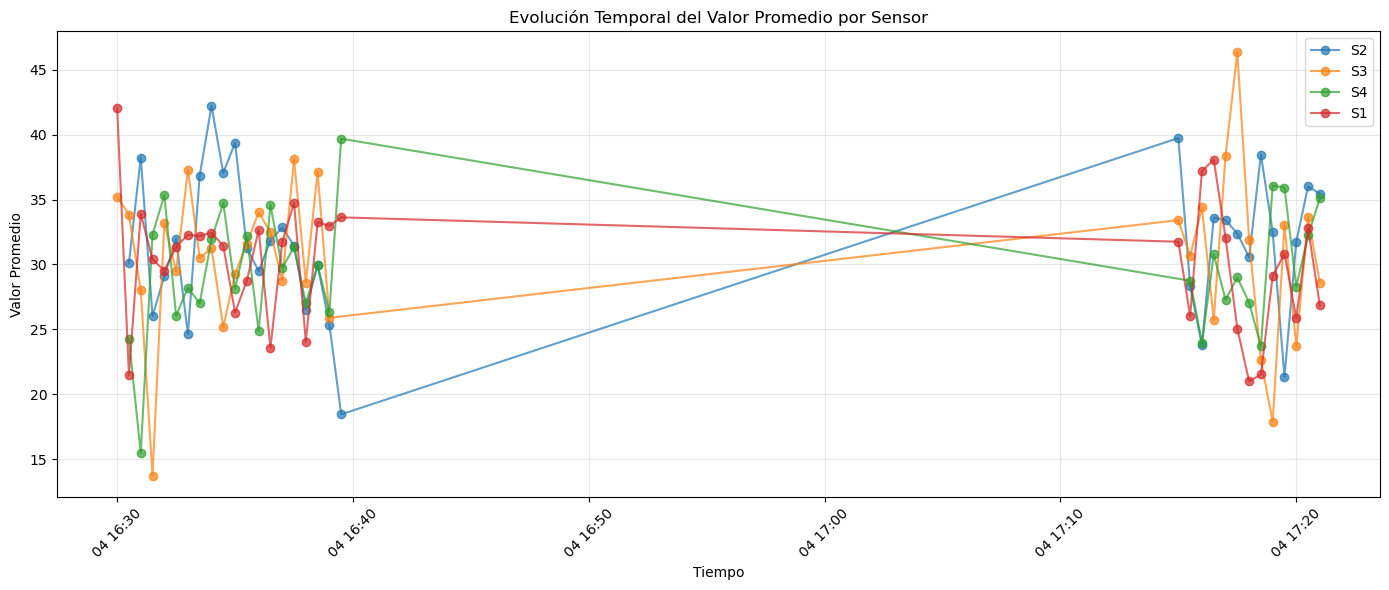

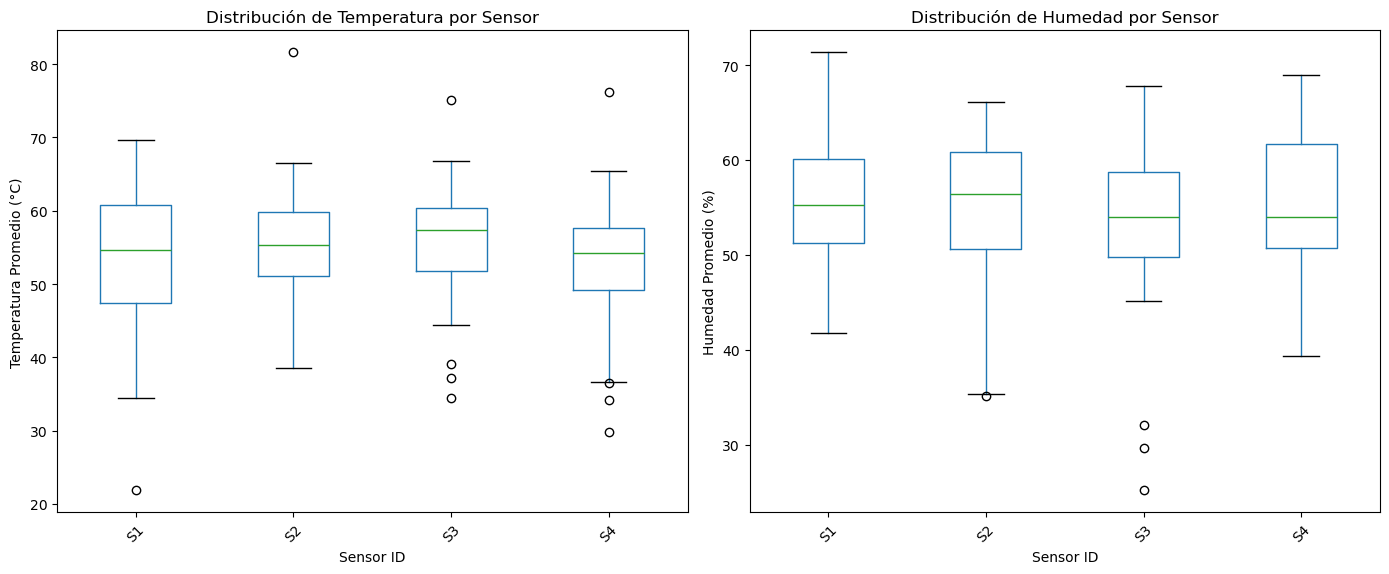

Gráficos generados exitosamente!


In [43]:
### Ejercicio 11
# Crea dos gráficos, convirtiendo el DF de spark a pandas y 
# utiliza la libreria matplotlib para generar dos gráficos sobre alguna de las variables.

import matplotlib.pyplot as plt
import pandas as pd

# Convertir a Pandas (limitamos registros para mejor rendimiento)
df_pandas = df_resultados.limit(1000).toPandas()

# Extraer el inicio de la ventana temporal para eje X
df_pandas['window_start'] = pd.to_datetime(df_pandas['window'].apply(lambda x: x['start']))

# GRÁFICO 1: Evolución temporal de avg_value por sensor
plt.figure(figsize=(14, 6))

for sensor in df_pandas['sensor_id'].unique():
    datos_sensor = df_pandas[df_pandas['sensor_id'] == sensor].sort_values('window_start')
    plt.plot(datos_sensor['window_start'], datos_sensor['avg_value'], 
             marker='o', label=sensor, alpha=0.7)

plt.xlabel('Tiempo')
plt.ylabel('Valor Promedio')
plt.title('Evolución Temporal del Valor Promedio por Sensor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GRÁFICO 2: Distribución de temperatura y humedad por sensor (boxplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot de temperatura
df_pandas.boxplot(column='avg_temp', by='sensor_id', ax=ax1, grid=False)
ax1.set_title('Distribución de Temperatura por Sensor')
ax1.set_xlabel('Sensor ID')
ax1.set_ylabel('Temperatura Promedio (°C)')
plt.sca(ax1)
plt.xticks(rotation=45)

# Boxplot de humedad
df_pandas.boxplot(column='avg_humidity', by='sensor_id', ax=ax2, grid=False)
ax2.set_title('Distribución de Humedad por Sensor')
ax2.set_xlabel('Sensor ID')
ax2.set_ylabel('Humedad Promedio (%)')
plt.sca(ax2)
plt.xticks(rotation=45)

# Ajustar el título general
fig.suptitle('')  # Eliminar el título automático del boxplot
plt.tight_layout()
plt.show()

print("Gráficos generados exitosamente!")